<a href="https://colab.research.google.com/github/JorgeMoragaCalvo/data-science-playground/blob/main/lab1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import sys
import time
import psutil
import matplotlib.pyplot as plt

t_cg = torch.manual_seed(1547)

In [ ]:
# Definicion clase red neuronal feedforward
class FFNN(torch.nn.Module):
  def __init__(self, d0=784, d1=128, d2=64, weight_init='he', dropout_rate=0.3):
    super(FFNN, self).__init__()
    self.weight_init = weight_init
    # Definicion capas lineales y de los modulos de BatchNorm y Dropout
    self.fc1 = torch.nn.Linear(d0, d1, bias=True)
    self.bn1 = torch.nn.BatchNorm1d(d1)
    self.dropout1 = torch.nn.Dropout(dropout_rate)

    self.fc2 = torch.nn.Linear(d1, d2, bias=True)
    self.bn2 = torch.nn.BatchNorm1d(d2)
    self.dropout2 = torch.nn.Dropout(dropout_rate)

    self.fc3 = torch.nn.Linear(d2, 10, bias=True)

    # Inicialización de peso
    #if weight_init == 'xavier':
    #  torch.nn.init.xavier_uniform_(self.fc1.weight)
    #  torch.nn.init.xavier_uniform_(self.fc2.weight)
    #  torch.nn.init.xavier_uniform_(self.fc3.weight)
    # Inicialización de pesos con el metodo He
    if weight_init == 'he':
      torch.nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
      torch.nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
      torch.nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity='relu')
    else:
      raise ValueError('Función de inicialización no reconocida')

  # metodo forward
  def forward(self, x):
    # Capa 1 con BatchNorm, ReLU y Dropout
    u1 = self.fc1(x)
    u1 = self.bn1(u1)
    h1 = torch.relu(u1)
    h1 = self.dropout1(h1) # Dropout

    # Capa 2 con BatchNorm, ReLU y Dropout
    u2 = self.fc2(u1)
    u2 = self.bn2(u2)
    h2 = torch.relu(u2)
    h2 = self.dropout2(h2)

    # Capa 3 y salida con softmax
    u3 = self.fc3(h2)
    y_pred = torch.softmax(u3, dim=1)
    return y_pred

In [ ]:
# TRAIN SPLIT
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler, TensorDataset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# transformaciones para normalizar y convertir las imagenes a tensores
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

# Carga del dataset MNIST con las transformaciones definidas
mnist_dataset = MNIST(root='./data', train=True, transform=transform, download=True)

# Preprocesamiento y normalizacion de los datos
data = mnist_dataset.data.float().view(-1, 784) / 255.0
targets = mnist_dataset.targets

# Division datos en entrenamiento, validacion y prueba
data_train, data_temp, targets_train, targets_temp = train_test_split(data, targets, test_size=0.2, random_state=42)
data_val, data_test, targets_val, targets_test = train_test_split(data_temp, targets_temp, test_size=0.5, random_state=42)

# Creacion de datasets de entrenamiento, validacion y prueba
train_dataset = TensorDataset(data_train, targets_train)
val_dataset = TensorDataset(data_val, targets_val)
test_dataset = TensorDataset(data_test, targets_test)

# Creacion de dataloaders para cargar los datos en batches durante el entrenamiento
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.77MB/s]


In [ ]:
# Funcion para crear muestras bootstrap a partir de un dataset dado
def create_bootstrap_samples(dataset, num_samples):
  bootstrap_datasets = []
  N = len(dataset)

  for _ in range(num_samples):
    indices = torch.randint(0, N, (N,))
    # Access data using indexing
    sampled_data = [dataset[i] for i in indices]
    sampled_X = torch.stack([data[0] for data in sampled_data])
    sampled_Y = torch.tensor([data[1] for data in sampled_data])
    bootstrap_dataset = torch.utils.data.TensorDataset(sampled_X, sampled_Y)
    bootstrap_datasets.append(bootstrap_dataset)

  return bootstrap_datasets

In [ ]:
# TRAIN SPLIT
# Clase para implementar early stopping durante el entrenamiento
class EarlyStopping:
    def __init__(self, patience=5, delta=1e-5):
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Funcion principal para entrenar un ensemble de redes FFNN en el
# dataset MNNIST
def loop_FFNN_ensemble_mnist(
    train_dataset, val_dataset, test_dataset, batch_size, d1, d2, lr, epochs,
    optimizer_name, init_method='he',
    run_in_GPU=True, reports_every=1, cheq_grad=False, dropout_rate=0.3,
    bootstrap_dataset=False):

    #train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    #val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    #test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Condifuracion del dispositivo (GPU o CPU)
    device = 'cuda' if run_in_GPU else 'cpu'
    d0 = 784
    net = FFNN(d0, d1, d2, init_method, dropout_rate=dropout_rate)
    net.to(device)
    print('Red: ', net)
    loss = torch.nn.CrossEntropyLoss()

    # Configuracion del optimizador
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(net.parameters(), lr, betas=(0.9, 0.999), weight_decay=0.0001)
    else:
        raise ValueError('Optimizador no reconocido')

    # Inicializar Early Stopping
    early_stopping = EarlyStopping(patience=10, delta=1e-5)

    val_losses = []
    accuracies = []

    epochs_time = 0

    # Ciclo de entrenamiento para cada epoca
    for e in range(1, epochs + 1):
        epoch_init = time.perf_counter()

        # Crear DataLoader de muestras bootstrap si es necesario
        if bootstrap_dataset:
            indices = np.random.choice(len(train_dataset), len(train_dataset), replace=True)
            sampler = SubsetRandomSampler(indices)
            current_train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
        else:
            current_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        net.train()
        for (x, y) in current_train_loader:
            x = x.view(-1, 784).to(device)
            y = y.to(device)
            #y_pred = net(x)  # Se usa net(x) en lugar de net.forward(x)
            y_pred = net.forward(x)
            L = loss(y_pred, y)
            L.backward()
            optimizer.step()
            optimizer.zero_grad()

        epochs_time += time.perf_counter() - epoch_init

        # Validación al final de cada epoca
        net.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for (x_val, y_val) in DataLoader(val_dataset, batch_size=batch_size, shuffle=False):
                x_val = x_val.view(-1, 784).to(device)
                y_val = y_val.to(device)
                y_val_pred = net(x_val)
                val_loss += loss(y_val_pred, y_val).item()
                _, predicted = torch.max(y_val_pred.data, 1)
                total += y_val.size(0)
                correct += (predicted == y_val).sum().item()

        val_loss /= len(val_dataset) // batch_size
        val_losses.append(val_loss)
        accuracy = 100 * correct / total
        accuracies.append(accuracy)

        # Actualizar Early Stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        if e % reports_every == 0:
            sys.stdout.write(
                '\rEpoch:{0:03d}'.format(e)
                + ' Val Acc:{0:.2f}%'.format(accuracy)
                + ' Val Loss:{0:.4f}'.format(val_loss)
                + ' Time/epoch:{0:.3f}s'.format(epochs_time/e))

    # Validacion del conjunto de prueba
    if test_dataset is not None:
        correct = 0
        total = 0
        with torch.no_grad():
            for (x_test, y_test) in DataLoader(test_dataset, batch_size=batch_size, shuffle=False):
                x_test = x_test.view(-1, 784).to(device)
                y_test = y_test.to(device)
                y_test_pred = net(x_test)
                _, predicted = torch.max(y_test_pred.data, 1)
                total += y_test.size(0)
                correct += (predicted == y_test).sum().item()
        test_accuracy = 100 * correct / total
        print(f'\nTest Accuracy: {test_accuracy:.2f}%')

    return val_losses, accuracies

In [ ]:
# TRAIN SPLIT
# Funcion para ejecutar experimentos de entrenamiento ensemble
def run_experiments_ensemble(dataset, val_dataset, test_dataset, batch_size,
                             d1, d2, lr, epochs, optimizers,
                             init_methods, num_models=2, reports_every=1):
  results = {}
  bootstrap_datasets = create_bootstrap_samples(train_loader.dataset, num_models)
  # Obtener num_features del dataset original
  num_features = 784

  for init in [init_methods]:
    for opt in [optimizers]:
      print(f"\n\nTraining with {opt} optimizer and {init} initialization...")
      # Iterar sobre cada bootstrap dataset
      for bootstrap_dataset in bootstrap_datasets:
        # train_loader_bootstrap = DataLoader(bootstrap_dataset, batch_size=batch_size, shuffle=True)
        val_losses, accuracies = loop_FFNN_ensemble_mnist(bootstrap_dataset, val_dataset, test_dataset,
                                                          batch_size, d1, d2, lr, epochs,
                                                          opt, init_method=init, run_in_GPU=False,
                                                          reports_every=reports_every, cheq_grad=False,
                                                          bootstrap_dataset=True)
        # Almacenar los resultados usando una clave unica (opt, init) para cada modelo de bootstrap
        results[(opt, init)] = (val_losses, accuracies)

  plot_results(results)

# Funcion para graficar los resultados de accuracy y loss
def plot_results(results):
  plt.figure(figsize=(12, 5))

  # Gráfica de pérdida
  plt.subplot(1, 2, 1)
  for (opt, init), (val_losses, _) in results.items():
    plt.plot(val_losses, label=f'{opt}  ({init})')
  plt.title('Loss vs. Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  # Gráfica de precisión
  plt.subplot(1, 2, 2)
  for (opt, init), (_, accuracies) in results.items():
    plt.plot(accuracies, label=f'{opt}  ({init})')
  plt.title('Accuracy vs. Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()



Training with Adam optimizer and he initialization...
Red:  FFNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Epoch:044 Val Acc:95.57% Val Loss:1.5163 Time/epoch:6.664sEarly stopping

Test Accuracy: 95.52%
Red:  FFNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.

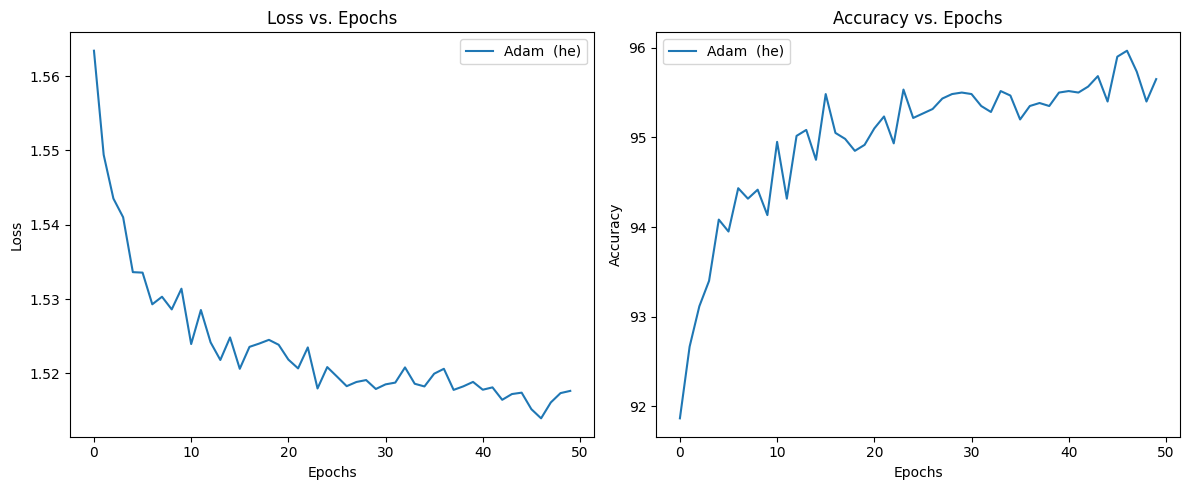

In [ ]:
dataset = train_dataset

epochs = 50
run_experiments_ensemble(dataset=dataset,
                         val_dataset=val_dataset,
                         test_dataset=test_dataset,
                         batch_size=32,
                         d1=128,
                         d2=64,
                         lr=0.001,
                         epochs=epochs,
                         optimizers='Adam',
                         init_methods='he',
                         num_models=2,
                         reports_every=1)